In [6]:
!pip install -q segmentation-models-pytorch albumentations

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
from google.colab import drive
drive.mount('/content/drive')

# ── Update this to your actual folder structure ──────────────────────────────
DRIVE_ROOT   = "/content/drive/MyDrive"          # base of your Drive
DATASET_DIR  = f"{DRIVE_ROOT}/FYP/FYP/data"        # folder containing images/ and masks/
IMAGE_DIR    = f"{DATASET_DIR}/images"
MASK_DIR     = f"{DATASET_DIR}/masks"

import os
print("Images found:", len(os.listdir(IMAGE_DIR)))
print("Masks found :", len(os.listdir(MASK_DIR)))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Images found: 3049
Masks found : 3049


In [13]:
import os, cv2, numpy as np, torch
from torch.utils.data import Dataset, DataLoader, Subset
import albumentations as A
from albumentations.pytorch import ToTensorV2

# ── Step 1: Build mapping (RUN ONCE) ───────────────────────────────────
all_values = set()

for fname in os.listdir(MASK_DIR):
    mask = cv2.imread(os.path.join(MASK_DIR, fname), 0)
    all_values.update(np.unique(mask).tolist())

all_values = sorted(all_values)
mapping = {v: i for i, v in enumerate(all_values)}

NUM_CLASSES = len(mapping)
IMAGE_SIZE  = 256

print("NUM_CLASSES:", NUM_CLASSES)


# ── Dataset ────────────────────────────────────────────────────────────
class OCTDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir  = mask_dir
        self.ids = sorted([f for f in os.listdir(image_dir)
                           if f.lower().endswith(('.png','.jpg','.tif','.bmp'))])
        self.transform = transform

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        fname = self.ids[idx]

        img  = cv2.imread(os.path.join(self.image_dir, fname), cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(os.path.join(self.mask_dir,  fname), cv2.IMREAD_GRAYSCALE)

        # Resize first
        img  = cv2.resize(img,  (IMAGE_SIZE, IMAGE_SIZE))
        mask = cv2.resize(mask, (IMAGE_SIZE, IMAGE_SIZE), interpolation=cv2.INTER_NEAREST)

        # ✅ Remap labels (CRITICAL FIX)
        mask = np.vectorize(mapping.get)(mask)

        # Safety check
        if mask.max() >= NUM_CLASSES:
            raise ValueError(f"Invalid class index: {mask.max()}")

        if self.transform:
            aug  = self.transform(image=img, mask=mask)
            img  = aug['image']
            mask = aug['mask'].long()
        else:
            img  = torch.tensor(img, dtype=torch.float32).unsqueeze(0) / 255.0
            mask = torch.tensor(mask, dtype=torch.long)

        return img, mask


# ── Transforms ─────────────────────────────────────────────────────────
def get_transforms(train=True):
    if train:
        return A.Compose([
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.3),
            A.RandomRotate90(p=0.3),
            A.RandomBrightnessContrast(p=0.3),
            A.GaussNoise(p=0.2),
            A.Normalize(mean=(0.5,), std=(0.5,), max_pixel_value=255.0),
            ToTensorV2(),
        ])
    return A.Compose([
        A.Normalize(mean=(0.5,), std=(0.5,), max_pixel_value=255.0),
        ToTensorV2(),
    ])


# ── Step 2: Proper split with separate datasets ─────────────────────────
full_indices = list(range(len(os.listdir(IMAGE_DIR))))

n = len(full_indices)
n_train = int(0.7 * n)
n_val   = int(0.15 * n)
n_test  = n - n_train - n_val

train_idx, val_idx, test_idx = torch.utils.data.random_split(
    full_indices,
    [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(42)
)

# Create separate dataset instances
train_ds = Subset(
    OCTDataset(IMAGE_DIR, MASK_DIR, transform=get_transforms(True)),
    train_idx.indices
)

val_ds = Subset(
    OCTDataset(IMAGE_DIR, MASK_DIR, transform=get_transforms(False)),
    val_idx.indices
)

test_ds = Subset(
    OCTDataset(IMAGE_DIR, MASK_DIR, transform=get_transforms(False)),
    test_idx.indices
)


# ── DataLoaders ────────────────────────────────────────────────────────
train_loader = DataLoader(train_ds, batch_size=8, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=8, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=8, shuffle=False, num_workers=2)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

NUM_CLASSES: 202
Train: 2134 | Val: 457 | Test: 458


In [14]:
import torch.nn as nn
import torch.nn.functional as F


class ConvBlock(nn.Module):
    """Two Conv→BN→ReLU layers."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.block(x)


class BaselineUNet(nn.Module):
    def __init__(self, in_channels=1, num_classes=NUM_CLASSES, base_ch=64):
        super().__init__()
        # Encoder
        self.enc1 = ConvBlock(in_channels, base_ch)
        self.enc2 = ConvBlock(base_ch,     base_ch*2)
        self.enc3 = ConvBlock(base_ch*2,   base_ch*4)
        self.enc4 = ConvBlock(base_ch*4,   base_ch*8)
        self.pool = nn.MaxPool2d(2)
        # Bottleneck
        self.bottleneck = ConvBlock(base_ch*8, base_ch*16)
        # Decoder
        self.up4   = nn.ConvTranspose2d(base_ch*16, base_ch*8,  2, stride=2)
        self.dec4  = ConvBlock(base_ch*16, base_ch*8)
        self.up3   = nn.ConvTranspose2d(base_ch*8,  base_ch*4,  2, stride=2)
        self.dec3  = ConvBlock(base_ch*8,  base_ch*4)
        self.up2   = nn.ConvTranspose2d(base_ch*4,  base_ch*2,  2, stride=2)
        self.dec2  = ConvBlock(base_ch*4,  base_ch*2)
        self.up1   = nn.ConvTranspose2d(base_ch*2,  base_ch,    2, stride=2)
        self.dec1  = ConvBlock(base_ch*2,  base_ch)
        # Head
        self.head  = nn.Conv2d(base_ch, num_classes, 1)

    def forward(self, x):
        # Encoder path
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        # Bottleneck
        b  = self.bottleneck(self.pool(e4))
        # Decoder path (with skip connections)
        d4 = self.dec4(torch.cat([self.up4(b),  e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.head(d1)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = BaselineUNet(in_channels=1, num_classes=NUM_CLASSES).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Device: {device}")
print(f"Total parameters: {total_params:,}  ({total_params/1e6:.2f}M)")

Device: cuda
Total parameters: 31,049,546  (31.05M)


In [15]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, preds, targets):
        preds   = F.softmax(preds, dim=1)
        one_hot = F.one_hot(targets, NUM_CLASSES).permute(0,3,1,2).float()
        inter   = (preds * one_hot).sum(dim=(2,3))
        union   = preds.sum(dim=(2,3)) + one_hot.sum(dim=(2,3))
        dice    = (2 * inter + self.smooth) / (union + self.smooth)
        return 1 - dice.mean()


class CombinedLoss(nn.Module):
    def __init__(self, alpha=0.5):
        super().__init__()
        self.ce   = nn.CrossEntropyLoss()
        self.dice = DiceLoss()
        self.alpha = alpha

    def forward(self, preds, targets):
        return self.alpha * self.ce(preds, targets) + (1 - self.alpha) * self.dice(preds, targets)


def dice_score(preds, targets, num_classes=NUM_CLASSES, smooth=1e-6):
    """Mean Dice score across all classes."""
    preds = preds.argmax(dim=1)
    scores = []
    for c in range(num_classes):
        p = (preds == c).float()
        t = (targets == c).float()
        inter = (p * t).sum()
        scores.append((2 * inter + smooth) / (p.sum() + t.sum() + smooth))
    return torch.stack(scores).mean().item()


def iou_score(preds, targets, num_classes=NUM_CLASSES, smooth=1e-6):
    """Mean IoU across all classes."""
    preds = preds.argmax(dim=1)
    scores = []
    for c in range(num_classes):
        p = (preds == c).float()
        t = (targets == c).float()
        inter = (p * t).sum()
        union = p.sum() + t.sum() - inter
        scores.append((inter + smooth) / (union + smooth))
    return torch.stack(scores).mean().item()

In [16]:
from torch.optim.lr_scheduler import CosineAnnealingLR

NUM_EPOCHS = 50
LR         = 1e-4

criterion = CombinedLoss(alpha=0.5)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

history = {'train_loss': [], 'val_loss': [], 'val_dice': [], 'val_iou': []}
best_dice = 0.0
CKPT_PATH = "/content/drive/MyDrive/wet_amd_unet_baseline_best.pth"


def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, total_dice, total_iou = 0, 0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for imgs, masks in loader:
            imgs, masks = imgs.to(device), masks.to(device)
            preds = model(imgs)
            loss  = criterion(preds, masks)
            if train:
                optimizer.zero_grad(); loss.backward(); optimizer.step()
            total_loss += loss.item()
            total_dice += dice_score(preds.detach(), masks)
            total_iou  += iou_score(preds.detach(), masks)
    n = len(loader)
    return total_loss/n, total_dice/n, total_iou/n


for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, _, _               = run_epoch(train_loader, train=True)
    val_loss, val_dice, val_iou = run_epoch(val_loader,   train=False)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(val_loss)
    history['val_dice'].append(val_dice)
    history['val_iou'].append(val_iou)

    if val_dice > best_dice:
        best_dice = val_dice
        torch.save({'epoch': epoch, 'model_state': model.state_dict(),
                    'dice': best_dice}, CKPT_PATH)
        saved = " ✓ saved"
    else:
        saved = ""

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{NUM_EPOCHS} | "
              f"Train Loss: {tr_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | "
              f"Val Dice: {val_dice:.4f} | "
              f"Val IoU: {val_iou:.4f}{saved}")

print(f"\nBest Val Dice: {best_dice:.4f}")

Epoch   1/50 | Train Loss: 2.6149 | Val Loss: 2.1972 | Val Dice: 0.3714 | Val IoU: 0.3710 ✓ saved


KeyboardInterrupt: 

Loaded checkpoint from epoch 4 (Dice=0.4020)

Test Loss: 0.9293 | Test Dice: 0.3988 | Test IoU: 0.3973


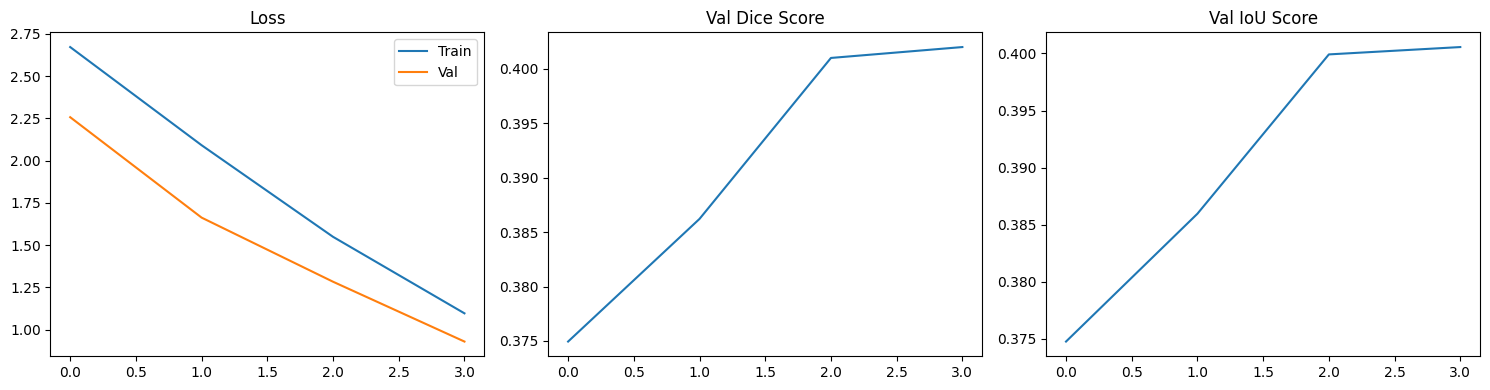

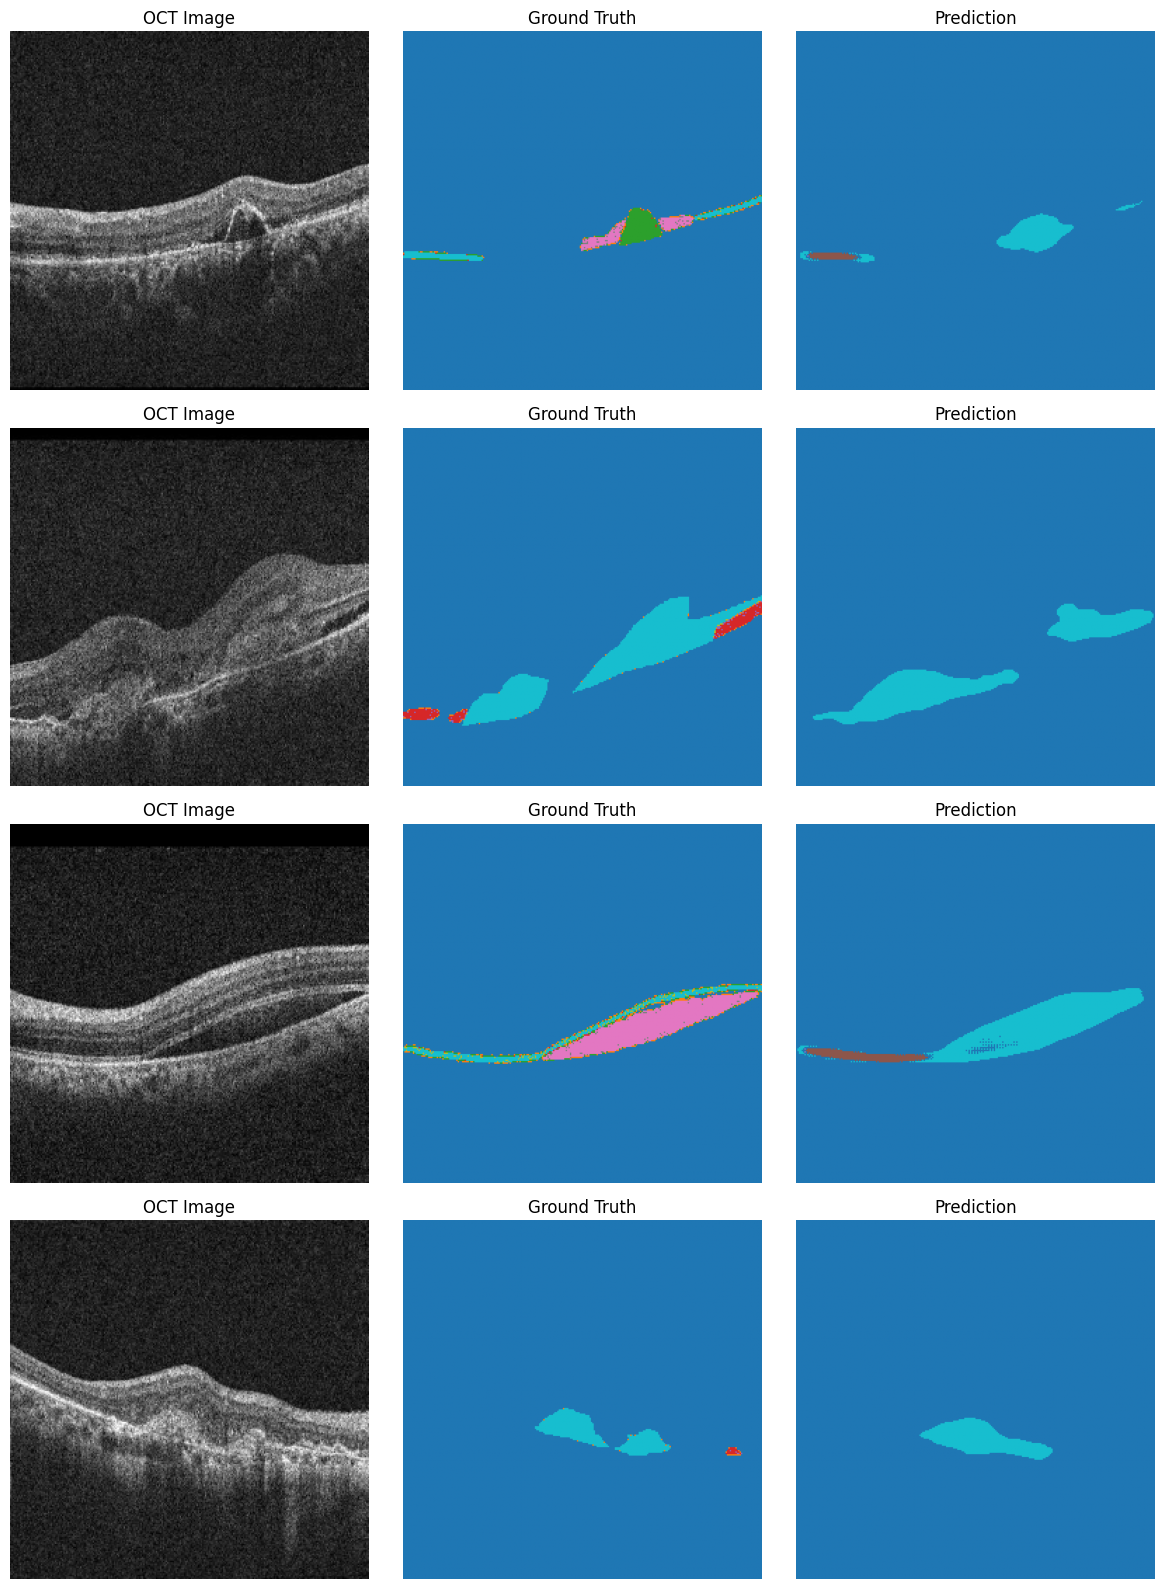

In [ ]:
import matplotlib.pyplot as plt

# ── Load best checkpoint ──────────────────────────────────────────────────────
ckpt = torch.load(CKPT_PATH, map_location=device)
model.load_state_dict(ckpt['model_state'])
print(f"Loaded checkpoint from epoch {ckpt['epoch']} (Dice={ckpt['dice']:.4f})")

# ── Test set evaluation ───────────────────────────────────────────────────────
test_loss, test_dice, test_iou = run_epoch(test_loader, train=False)
print(f"\nTest Loss: {test_loss:.4f} | Test Dice: {test_dice:.4f} | Test IoU: {test_iou:.4f}")

# ── Training curves ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(history['train_loss'], label='Train'); axes[0].plot(history['val_loss'], label='Val')
axes[0].set_title('Loss'); axes[0].legend()
axes[1].plot(history['val_dice']); axes[1].set_title('Val Dice Score')
axes[2].plot(history['val_iou']);  axes[2].set_title('Val IoU Score')
plt.tight_layout(); plt.savefig('/content/training_curves.png', dpi=150)
plt.show()

# ── Qualitative prediction samples ───────────────────────────────────────────
model.eval()
imgs, masks = next(iter(test_loader))
with torch.no_grad():
    preds = model(imgs.to(device)).argmax(dim=1).cpu()

fig, axes = plt.subplots(4, 3, figsize=(12, 16))
for i in range(4):
    img_np  = imgs[i].squeeze().numpy()
    mask_np = masks[i].numpy()
    pred_np = preds[i].numpy()
    axes[i,0].imshow(img_np,  cmap='gray');    axes[i,0].set_title('OCT Image')
    axes[i,1].imshow(mask_np, cmap='tab10');   axes[i,1].set_title('Ground Truth')
    axes[i,2].imshow(pred_np, cmap='tab10');   axes[i,2].set_title('Prediction')
    for ax in axes[i]: ax.axis('off')
plt.tight_layout(); plt.savefig('/content/sample_predictions.png', dpi=150)
plt.show()

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ChannelAttention(nn.Module):
    """Learns WHAT features to focus on across channels."""
    def __init__(self, in_ch, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.mlp = nn.Sequential(
            nn.Conv2d(in_ch, in_ch // reduction, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_ch // reduction, in_ch, 1, bias=False),
        )

    def forward(self, x):
        avg = self.mlp(self.avg_pool(x))
        max = self.mlp(self.max_pool(x))
        return x * torch.sigmoid(avg + max)


class SpatialAttention(nn.Module):
    """Learns WHERE in the image to focus."""
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size,
                              padding=kernel_size // 2, bias=False)

    def forward(self, x):
        avg = x.mean(dim=1, keepdim=True)        # average across channels
        max, _ = x.max(dim=1, keepdim=True)      # max across channels
        attn = torch.sigmoid(self.conv(torch.cat([avg, max], dim=1)))
        return x * attn


class CBAM(nn.Module):
    """Channel + Spatial attention applied sequentially."""
    def __init__(self, in_ch, reduction=16, kernel_size=7):
        super().__init__()
        self.channel  = ChannelAttention(in_ch, reduction)
        self.spatial  = SpatialAttention(kernel_size)

    def forward(self, x):
        x = self.channel(x)
        x = self.spatial(x)
        return x

print("CBAM defined successfully")

CBAM defined successfully


In [ ]:
class AttentionGate(nn.Module):
    """
    Filters skip connection features — only passes
    spatially relevant regions to the decoder.
    g = decoder signal (gating), x = encoder skip features
    """
    def __init__(self, g_ch, x_ch, inter_ch):
        super().__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(g_ch, inter_ch, 1, bias=False),
            nn.BatchNorm2d(inter_ch)
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(x_ch, inter_ch, 1, bias=False),
            nn.BatchNorm2d(inter_ch)
        )
        self.psi = nn.Sequential(
            nn.Conv2d(inter_ch, 1, 1, bias=False),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )

    def forward(self, g, x):
        # Upsample g to match x spatial size if needed
        if g.shape[2:] != x.shape[2:]:
            g = F.interpolate(g, size=x.shape[2:], mode='bilinear', align_corners=True)
        attn = torch.relu(self.W_g(g) + self.W_x(x))
        attn = self.psi(attn)          # attention map [B, 1, H, W]
        return x * attn                # filtered skip features


class AttentionUNet(nn.Module):
    """
    U-Net with:
      - CBAM after every encoder block  (what + where to focus)
      - Attention Gates on every skip connection (filter before concat)
    """
    def __init__(self, in_channels=1, num_classes=NUM_CLASSES, base_ch=64):
        super().__init__()
        b = base_ch

        # ── Encoder ──────────────────────────────────────────────────────────
        self.enc1 = ConvBlock(in_channels, b)  ;  self.cbam1 = CBAM(b)
        self.enc2 = ConvBlock(b,    b*2)       ;  self.cbam2 = CBAM(b*2)
        self.enc3 = ConvBlock(b*2,  b*4)       ;  self.cbam3 = CBAM(b*4)
        self.enc4 = ConvBlock(b*4,  b*8)       ;  self.cbam4 = CBAM(b*8)
        self.pool = nn.MaxPool2d(2)

        # ── Bottleneck ────────────────────────────────────────────────────────
        self.bottleneck = ConvBlock(b*8, b*16)

        # ── Attention Gates ───────────────────────────────────────────────────
        self.ag4 = AttentionGate(g_ch=b*16, x_ch=b*8,  inter_ch=b*8)
        self.ag3 = AttentionGate(g_ch=b*8,  x_ch=b*4,  inter_ch=b*4)
        self.ag2 = AttentionGate(g_ch=b*4,  x_ch=b*2,  inter_ch=b*2)
        self.ag1 = AttentionGate(g_ch=b*2,  x_ch=b,    inter_ch=b)

        # ── Decoder ───────────────────────────────────────────────────────────
        self.up4  = nn.ConvTranspose2d(b*16, b*8,  2, stride=2)
        self.dec4 = ConvBlock(b*16, b*8)

        self.up3  = nn.ConvTranspose2d(b*8,  b*4,  2, stride=2)
        self.dec3 = ConvBlock(b*8,  b*4)

        self.up2  = nn.ConvTranspose2d(b*4,  b*2,  2, stride=2)
        self.dec2 = ConvBlock(b*4,  b*2)

        self.up1  = nn.ConvTranspose2d(b*2,  b,    2, stride=2)
        self.dec1 = ConvBlock(b*2,  b)

        # ── Output head ───────────────────────────────────────────────────────
        self.head = nn.Conv2d(b, num_classes, 1)

    def forward(self, x):
        # Encoder + CBAM
        e1 = self.cbam1(self.enc1(x))
        e2 = self.cbam2(self.enc2(self.pool(e1)))
        e3 = self.cbam3(self.enc3(self.pool(e2)))
        e4 = self.cbam4(self.enc4(self.pool(e3)))

        # Bottleneck
        b  = self.bottleneck(self.pool(e4))

        # Decoder + Attention Gates on skip connections
        d4 = self.dec4(torch.cat([self.up4(b),  self.ag4(b,  e4)], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), self.ag3(d4, e3)], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), self.ag2(d3, e2)], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), self.ag1(d2, e1)], dim=1))

        return self.head(d1)


# Build the model
attn_model = AttentionUNet(in_channels=1, num_classes=NUM_CLASSES).to(device)

baseline_params = sum(p.numel() for p in model.parameters())
attn_params     = sum(p.numel() for p in attn_model.parameters())

print(f"Baseline U-Net params : {baseline_params:,}  ({baseline_params/1e6:.2f}M)")
print(f"Attention U-Net params: {attn_params:,}  ({attn_params/1e6:.2f}M)")
print(f"Extra params from attention: {attn_params - baseline_params:,}")

Baseline U-Net params : 31,049,546  (31.05M)
Attention U-Net params: 32,142,746  (32.14M)
Extra params from attention: 1,093,200


In [ ]:
from torch.optim.lr_scheduler import CosineAnnealingLR

NUM_EPOCHS = 50
LR         = 1e-4

attn_criterion = CombinedLoss(alpha=0.5)
attn_optimizer = torch.optim.Adam(attn_model.parameters(), lr=LR, weight_decay=1e-5)
attn_scheduler = CosineAnnealingLR(attn_optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

attn_history = {'train_loss': [], 'val_loss': [], 'val_dice': [], 'val_iou': []}
best_attn_dice = 0.0
ATTN_CKPT_PATH = "/content/drive/MyDrive/wet_amd_unet_attention_best.pth"


def run_epoch_model(loader, net, optimizer=None, train=True):
    """Generic epoch runner — works for any model."""
    net.train() if train else net.eval()
    total_loss = total_dice = total_iou = 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for imgs, masks in loader:
            imgs, masks = imgs.to(device), masks.to(device)
            preds = net(imgs)
            loss  = attn_criterion(preds, masks)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item()
            total_dice += dice_score(preds.detach(), masks)
            total_iou  += iou_score(preds.detach(),  masks)
    n = len(loader)
    return total_loss / n, total_dice / n, total_iou / n


print("Training Attention U-Net...\n")
for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, _, _ = run_epoch_model(
        train_loader, attn_model, attn_optimizer, train=True)
    val_loss, val_dice, val_iou = run_epoch_model(
        val_loader, attn_model, train=False)
    attn_scheduler.step()

    attn_history['train_loss'].append(tr_loss)
    attn_history['val_loss'].append(val_loss)
    attn_history['val_dice'].append(val_dice)
    attn_history['val_iou'].append(val_iou)

    if val_dice > best_attn_dice:
        best_attn_dice = val_dice
        torch.save({'epoch': epoch,
                    'model_state': attn_model.state_dict(),
                    'dice': best_attn_dice}, ATTN_CKPT_PATH)
        saved = " ✓ saved"
    else:
        saved = ""

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{NUM_EPOCHS} | "
              f"Train Loss: {tr_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | "
              f"Val Dice: {val_dice:.4f} | "
              f"Val IoU: {val_iou:.4f}{saved}")

print(f"\nBest Attention U-Net Val Dice: {best_attn_dice:.4f}")

Training Attention U-Net...

Epoch   1/50 | Train Loss: 2.5470 | Val Loss: 2.1783 | Val Dice: 0.3795 | Val IoU: 0.3784 ✓ saved


KeyboardInterrupt: 

Loaded attention checkpoint — epoch 2 (Dice=0.4018)

── Test Set Results ──────────────────────────────────
Model                      Loss     Dice      IoU
Baseline U-Net           0.9293   0.3988   0.3973
Attention U-Net          1.5275   0.3979   0.3968

Dice improvement: -0.24%


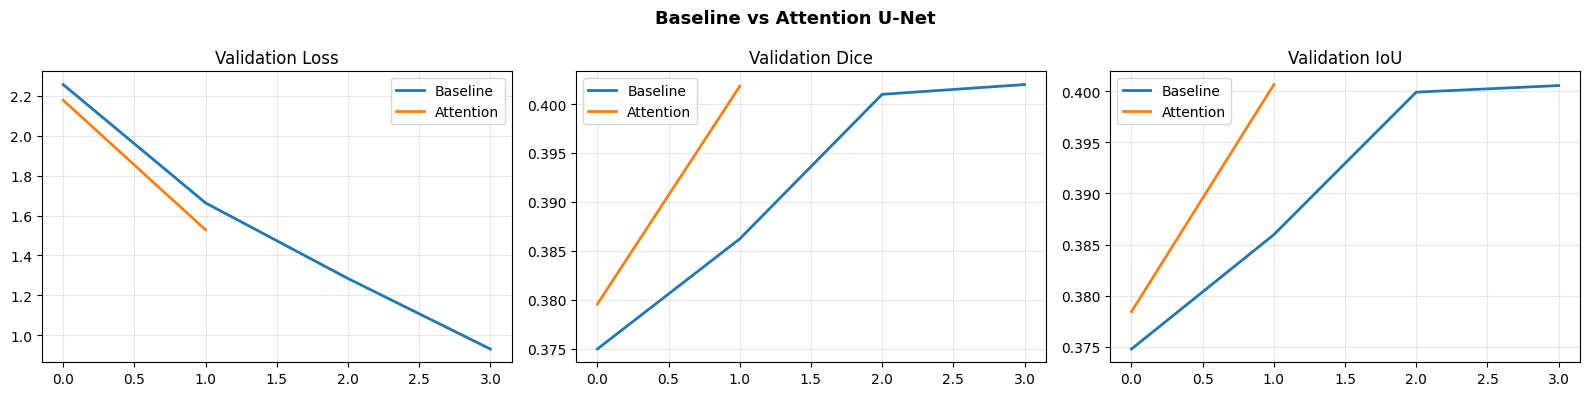

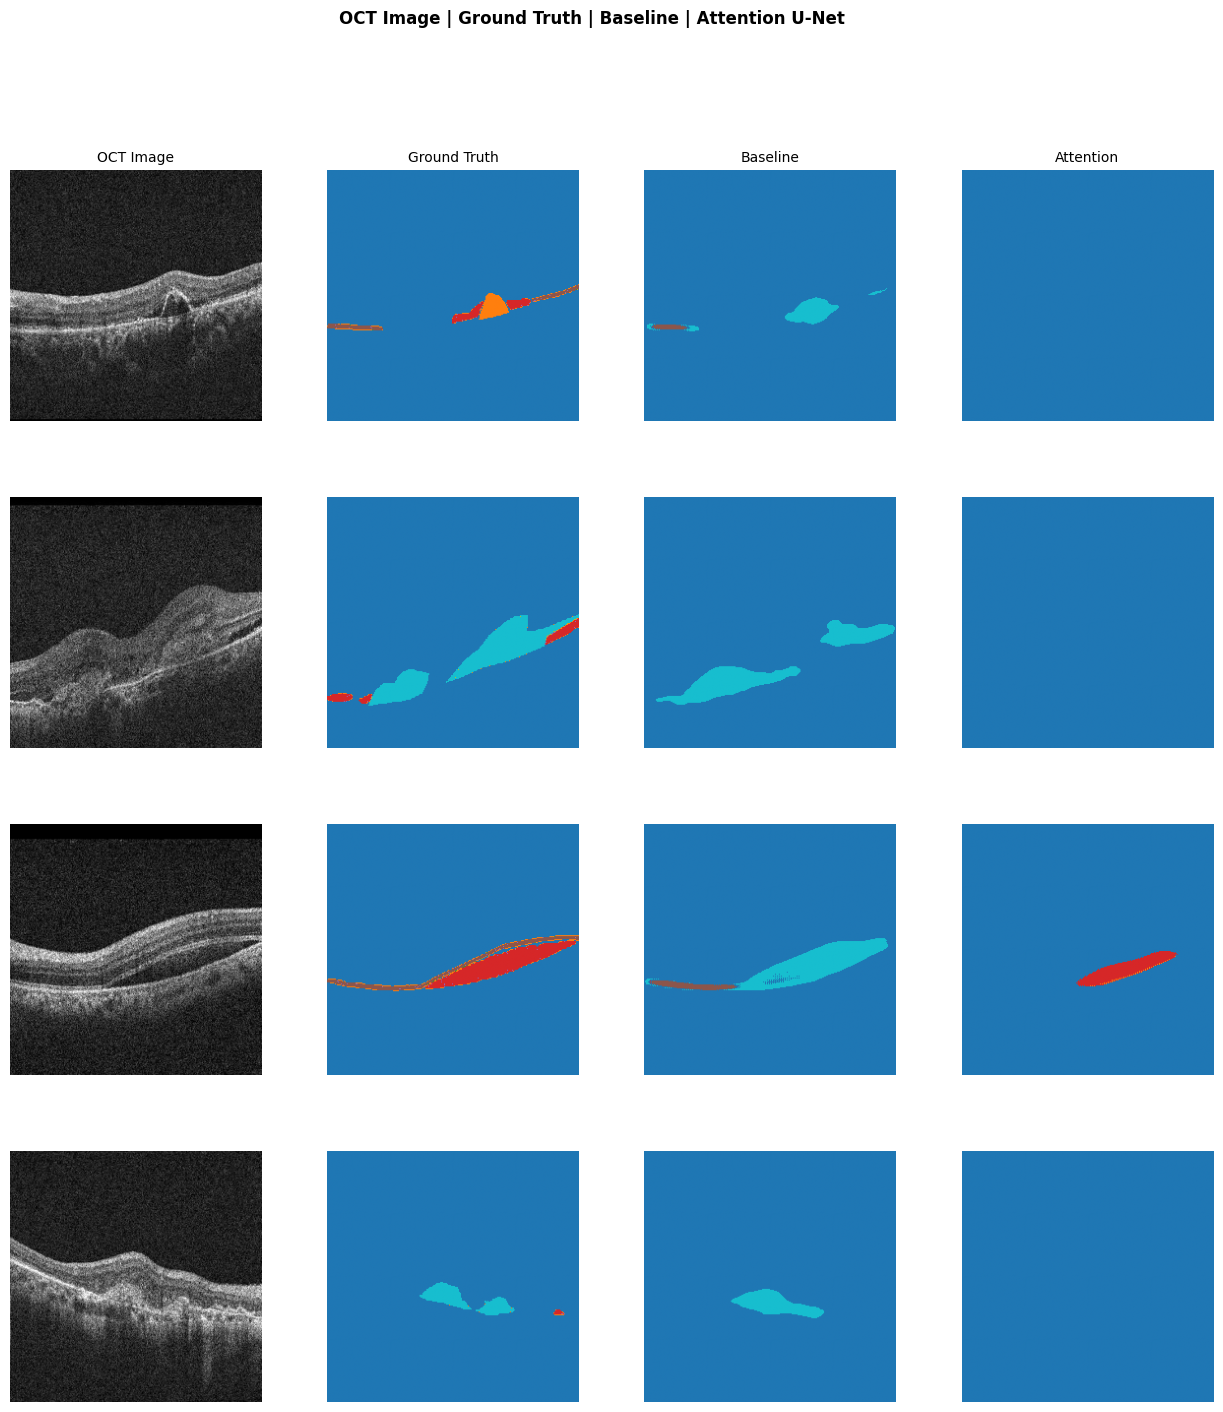

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Load best attention checkpoint ────────────────────────────────────────────
ckpt = torch.load(ATTN_CKPT_PATH, map_location=device)
attn_model.load_state_dict(ckpt['model_state'])
print(f"Loaded attention checkpoint — epoch {ckpt['epoch']} (Dice={ckpt['dice']:.4f})")

# ── Test set scores ───────────────────────────────────────────────────────────
base_loss, base_dice, base_iou = run_epoch(test_loader, train=False)
attn_loss, attn_dice, attn_iou = run_epoch_model(test_loader, attn_model, train=False)

print("\n── Test Set Results ──────────────────────────────────")
print(f"{'Model':<22} {'Loss':>8} {'Dice':>8} {'IoU':>8}")
print(f"{'Baseline U-Net':<22} {base_loss:>8.4f} {base_dice:>8.4f} {base_iou:>8.4f}")
print(f"{'Attention U-Net':<22} {attn_loss:>8.4f} {attn_dice:>8.4f} {attn_iou:>8.4f}")
improvement = (attn_dice - base_dice) / (base_dice + 1e-8) * 100
print(f"\nDice improvement: {improvement:+.2f}%")

# ── Training curves comparison ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Baseline vs Attention U-Net", fontsize=13, fontweight='bold')

axes[0].plot(history['val_loss'],      label='Baseline', linewidth=2)
axes[0].plot(attn_history['val_loss'], label='Attention', linewidth=2)
axes[0].set_title('Validation Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history['val_dice'],      label='Baseline', linewidth=2)
axes[1].plot(attn_history['val_dice'], label='Attention', linewidth=2)
axes[1].set_title('Validation Dice'); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(history['val_iou'],      label='Baseline', linewidth=2)
axes[2].plot(attn_history['val_iou'], label='Attention', linewidth=2)
axes[2].set_title('Validation IoU'); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/comparison_curves.png', dpi=150)
plt.show()

# ── Side-by-side predictions ──────────────────────────────────────────────────
model.eval(); attn_model.eval()
imgs, masks = next(iter(test_loader))

with torch.no_grad():
    base_preds = model(imgs.to(device)).argmax(dim=1).cpu()
    attn_preds = attn_model(imgs.to(device)).argmax(dim=1).cpu()

fig = plt.figure(figsize=(16, 16))
fig.suptitle("OCT Image | Ground Truth | Baseline | Attention U-Net",
             fontsize=12, fontweight='bold')
gs = gridspec.GridSpec(4, 4, figure=fig, hspace=0.3, wspace=0.1)

for i in range(4):
    img_np  = imgs[i].squeeze().numpy()
    mask_np = masks[i].numpy()
    base_np = base_preds[i].numpy()
    attn_np = attn_preds[i].numpy()

    ax0 = fig.add_subplot(gs[i, 0]); ax0.imshow(img_np,  cmap='gray')
    ax1 = fig.add_subplot(gs[i, 1]); ax1.imshow(mask_np, cmap='tab10', vmin=0, vmax=NUM_CLASSES-1)
    ax2 = fig.add_subplot(gs[i, 2]); ax2.imshow(base_np, cmap='tab10', vmin=0, vmax=NUM_CLASSES-1)
    ax3 = fig.add_subplot(gs[i, 3]); ax3.imshow(attn_np, cmap='tab10', vmin=0, vmax=NUM_CLASSES-1)

    for ax in [ax0, ax1, ax2, ax3]: ax.axis('off')
    if i == 0:
        for ax, t in zip([ax0,ax1,ax2,ax3],
                         ['OCT Image','Ground Truth','Baseline','Attention']):
            ax.set_title(t, fontsize=10)

plt.savefig('/content/side_by_side_predictions.png', dpi=150)
plt.show()

In [ ]:
import segmentation_models_pytorch as smp

print("=" * 60)
print("AVAILABLE ARCHITECTURES")
print("=" * 60)
architectures = {
    "unet"          : "U-Net           — fast, good baseline",
    "unetplusplus"  : "U-Net++         — more accurate than U-Net",
    "manet"         : "MAnet           — great for small lesions",
    "linknet"       : "LinkNet         — lightweight, fast inference",
    "fpn"           : "FPN             — good for multi-scale features",
    "pspnet"        : "PSPNet          — good for context understanding",
    "deeplabv3"     : "DeepLabV3       — strong semantic segmentation",
    "deeplabv3plus" : "DeepLabV3+      — best for thin layer boundaries",
    "pan"           : "PAN             — good feature aggregation",
}
for k, v in architectures.items():
    print(f"  {k:<20} {v}")

print("\n" + "=" * 60)
print("AVAILABLE ENCODERS (pretrained on ImageNet)")
print("=" * 60)
encoders = {
    "resnet34"         : "ResNet34         — fast, 21M params, good accuracy",
    "resnet50"         : "ResNet50         — balanced, 25M params",
    "resnet101"        : "ResNet101        — high accuracy, 44M params",
    "efficientnet-b0"  : "EfficientNet-B0  — very lightweight, 5M params",
    "efficientnet-b4"  : "EfficientNet-B4  — best accuracy/size, 19M params",
    "efficientnet-b7"  : "EfficientNet-B7  — highest accuracy, 66M params",
    "mobilenet_v2"     : "MobileNetV2      — ultra light, 3M params (edge deploy)",
    "densenet121"      : "DenseNet121      — good for medical imaging, 8M params",
    "densenet201"      : "DenseNet201      — stronger medical, 20M params",
    "vgg16"            : "VGG16            — classic, 14M params",
    "se_resnet50"      : "SE-ResNet50      — ResNet + channel attention, 28M params",
    "timm-efficientnet-b4" : "Timm EffNet-B4 — improved EfficientNet variant",
}
for k, v in encoders.items():
    print(f"  {k:<28} {v}")

print("\n" + "=" * 60)
print("TOP RECOMMENDATIONS FOR WET AMD OCT")
print("=" * 60)
recommendations = [
    ("1st", "unetplusplus", "efficientnet-b4",  "Best accuracy for small lesions"),
    ("2nd", "manet",        "densenet121",       "Best for medical imaging"),
    ("3rd", "deeplabv3plus","resnet50",          "Best for thin retinal layers"),
    ("4th", "unet",         "mobilenet_v2",      "Best for edge/low resource"),
    ("5th", "fpn",          "resnet34",          "Fast + decent accuracy"),
]
print(f"  {'Rank':<6} {'Architecture':<18} {'Encoder':<22} {'Why'}")
print("  " + "-" * 72)
for rank, arch, enc, why in recommendations:
    print(f"  {rank:<6} {arch:<18} {enc:<22} {why}")

ModuleNotFoundError: No module named 'segmentation_models_pytorch'